## Подбор метода удаления линий

In [2]:
import cv2
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt

Image: (5000, 5000, 3)
Polylines: 4
Mask pixels: 12403


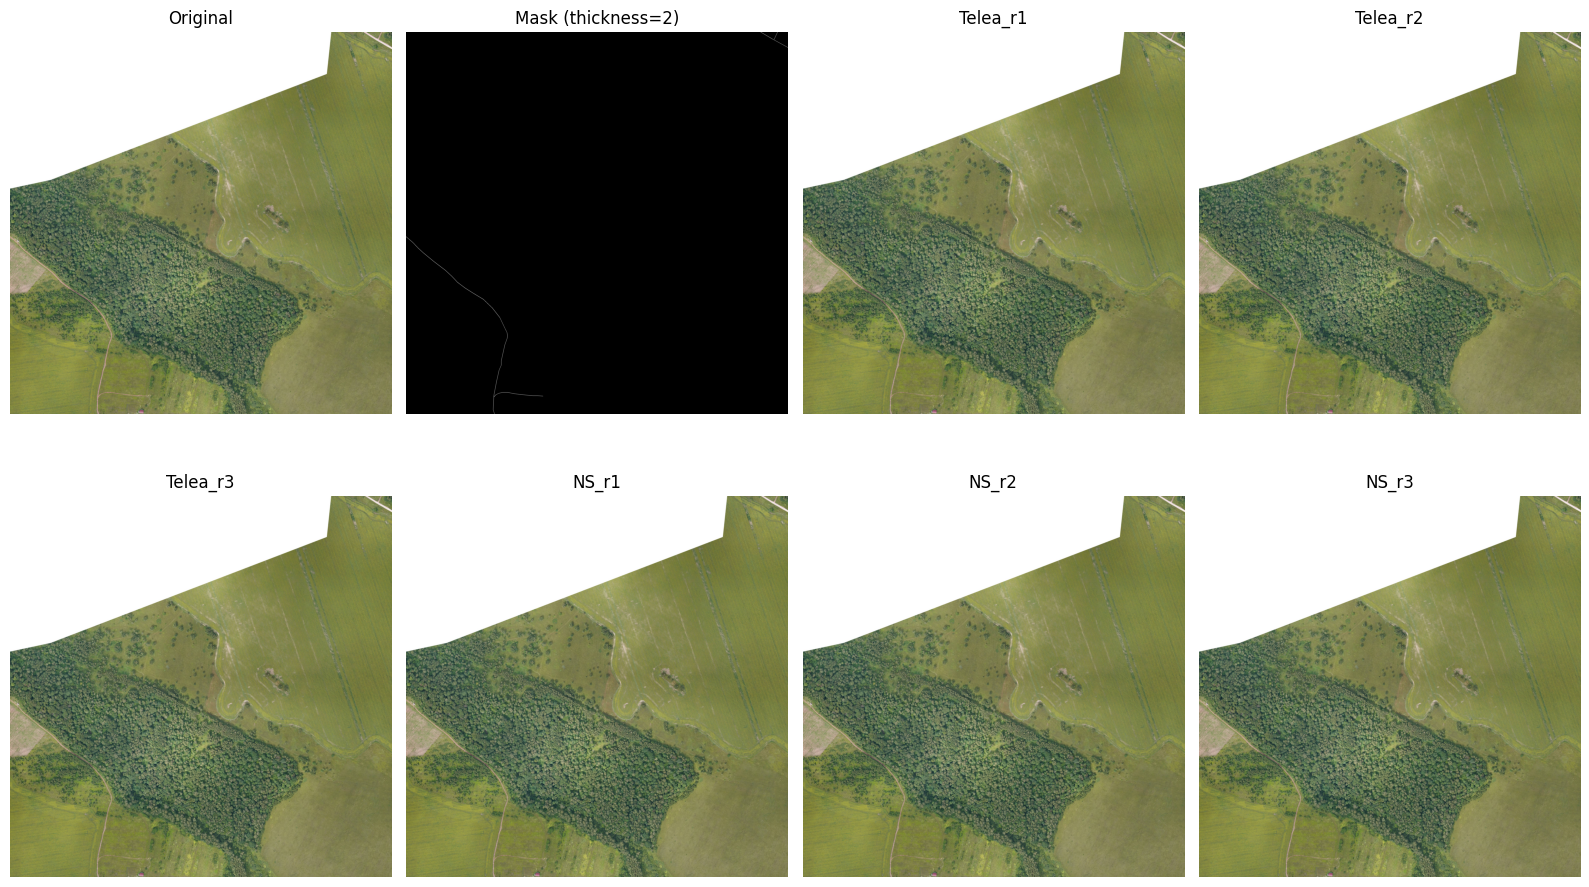

In [3]:
IMAGE_PATH = Path("C:/Recognition of unpaved roads/1_stage/images/2023_Alyoshnya_M2000-2-2.jpeg")
JSON_PATH = Path("C:/Recognition of unpaved roads/1_stage/annotations/2023_Alyoshnya_M2000-2-2.json")

LINE_THICKNESS = 2

image = cv2.imread(str(IMAGE_PATH))
with open(JSON_PATH, 'r') as f:
    annotation = json.load(f)

polylines = annotation.get('polylines', [])
print(f"Image: {image.shape}")
print(f"Polylines: {len(polylines)}")

mask = np.zeros(image.shape[:2], dtype=np.uint8)
for polyline in polylines:
    pts = np.array(polyline, dtype=np.int32)
    cv2.polylines(mask, [pts], isClosed=False, color=255, thickness=LINE_THICKNESS)

print(f"Mask pixels: {np.sum(mask > 0)}")

OUTPUT_DIR = Path("./line_removal_test")
OUTPUT_DIR.mkdir(exist_ok=True)

results = {}

for r in [1, 2, 3]:
    result = cv2.inpaint(image, mask, inpaintRadius=r, flags=cv2.INPAINT_TELEA)
    results[f"Telea_r{r}"] = result
    cv2.imwrite(str(OUTPUT_DIR / f"Telea_r{r}.jpg"), result)

for r in [1, 2, 3]:
    result = cv2.inpaint(image, mask, inpaintRadius=r, flags=cv2.INPAINT_NS)
    results[f"NS_r{r}"] = result
    cv2.imwrite(str(OUTPUT_DIR / f"NS_r{r}.jpg"), result)

for d in [1, 2]:
    dilated_mask = cv2.dilate(mask, np.ones((d*2+1, d*2+1), np.uint8), iterations=1)
    result = cv2.inpaint(image, dilated_mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    results[f"Telea_dilate{d}_r1"] = result
    cv2.imwrite(str(OUTPUT_DIR / f"Telea_dilate{d}_r1.jpg"), result)

cv2.imwrite(str(OUTPUT_DIR / "original.jpg"), image)
cv2.imwrite(str(OUTPUT_DIR / "mask.jpg"), mask)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title(f"Mask (thickness={LINE_THICKNESS})")
axes[1].axis('off')

for i, (name, result) in enumerate(list(results.items())[:6]):
    axes[i+2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    axes[i+2].set_title(name)
    axes[i+2].axis('off')

plt.tight_layout()
plt.show()